In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans

In [2]:
df=pd.read_csv(r"C:\Users\Jeevan kumar\Downloads\income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


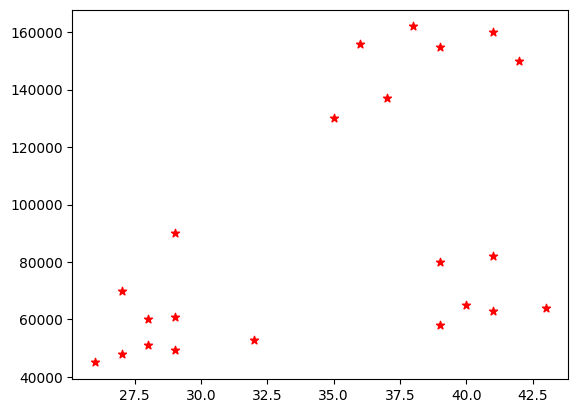

In [5]:
plt.scatter(df['Age'],df['Income($)'],marker='*',color='red')

In [13]:
km=KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [14]:
y_pred=km.fit_predict(df[['Age','Income($)']])
y_pred

array([2, 2, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0],
      dtype=int32)

In [15]:
df['y_pred']=y_pred
df.head()

,Name,Age,Income($),y_pred
0,Rob,27,70000,2
1,Michael,29,90000,2
2,Mohan,29,61000,0
3,Ismail,28,60000,0
4,Kory,42,150000,1


In [16]:
df1=df[df['y_pred']==0]
df2=df[df['y_pred']==1]
df3=df[df['y_pred']==2]

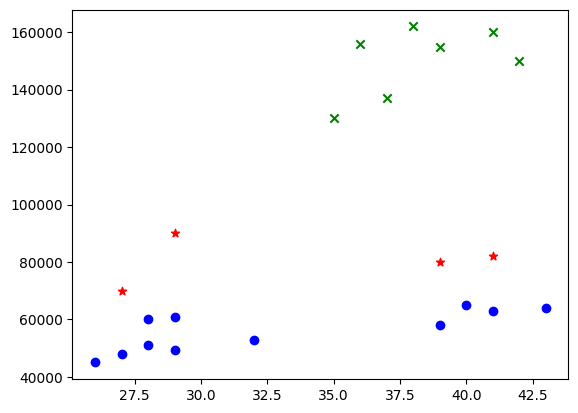

In [17]:
plt.scatter(df1['Age'],df1['Income($)'],marker='o',color='blue')
plt.scatter(df2['Age'],df2['Income($)'],marker='x',color='green')
plt.scatter(df3['Age'],df3['Income($)'],marker='*',color='red')
plt.show()

In [18]:
scaler=MinMaxScaler()
scaler.fit(df[['Income($)']])
df['Income($)']=scaler.transform(df[['Income($)']])
scaler.fit(df[['Age']])
df['Age']=scaler.transform(df[['Age']])

In [26]:
df.sample(5)

,Name,Age,Income($)
21,Abdul,0.764706,0.111111
2,Mohan,0.176471,0.136752
8,Brad,0.588235,0.948718
17,Priyanka,0.882353,0.153846
11,Tom,0.000000,0.000000


In [20]:
y_pred=km.fit_predict(df[['Age','Income($)']])
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [25]:
del df['y_pred']

In [27]:
df['Cluster']=y_pred

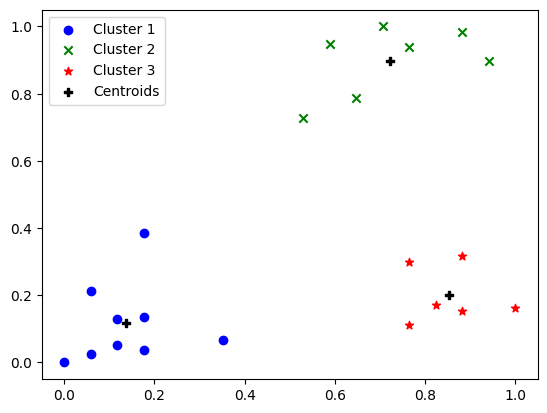

In [33]:
df1=df[df['Cluster']==0]
df2=df[df['Cluster']==1]
df3=df[df['Cluster']==2]

plt.scatter(df1['Age'],df1['Income($)'],marker='o',color='blue')
plt.scatter(df2['Age'],df2['Income($)'],marker='x',color='green')
plt.scatter(df3['Age'],df3['Income($)'],marker='*',color='red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],marker='P',color='black')
plt.legend(['Cluster 1','Cluster 2','Cluster 3','Centroids'])
plt.show()

In [30]:
km.cluster_centers_

array([[0.1372549 , 0.11633428],
       [0.72268908, 0.8974359 ],
       [0.85294118, 0.2022792 ]])

In [34]:
k_range=range(1,10)
sse=[]
for k in k_range:
    km=KMeans(n_clusters=k)
    km.fit(df[['Age','Income($)']])
    sse.append(km.inertia_)

In [35]:
sse

[5.434011511988179,
 2.4571335359046356,
 0.4750783498553096,
 0.3625079900797329,
 0.2768740621600469,
 0.28291418801817925,
 0.1685851223602976,
 0.1591933318857875,
 0.10497488680620909]

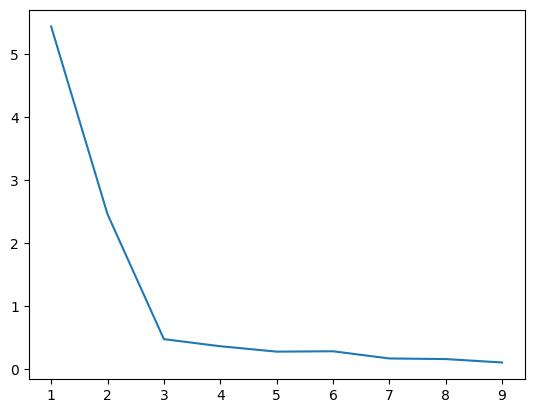

In [36]:
plt.plot(k_range,sse)

<h1>pratices

In [3]:
from sklearn.datasets import load_iris
data=load_iris()

In [4]:
s=pd.DataFrame(data.data,columns=data.feature_names)
s.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [5]:
del s['sepal width (cm)']
del s['sepal length (cm)']

In [6]:
km=KMeans(n_clusters=3)
clu=km.fit_predict(s)
clu

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 2, 0, 0, 2, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [7]:
s['cluster']=clu

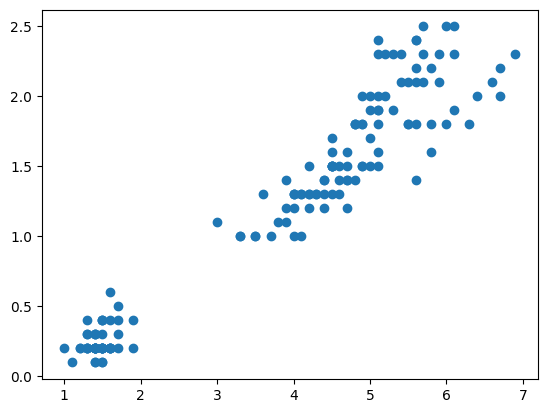

In [8]:
plt.scatter(s['petal length (cm)'],s['petal width (cm)'])

In [9]:
s.cluster.max()

np.int32(2)

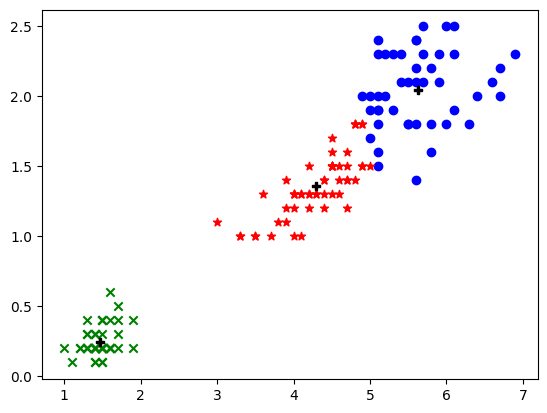

In [10]:
s1=s[s['cluster']==0]
s2=s[s['cluster']==1]
s3=s[s['cluster']==2]

plt.scatter(s1['petal length (cm)'],s1['petal width (cm)'],marker='o',color='blue')
plt.scatter(s2['petal length (cm)'],s2['petal width (cm)'],marker='x',color='green')
plt.scatter(s3['petal length (cm)'],s3['petal width (cm)'],marker='*',color='red')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],marker='P',color='black')


In [11]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(s)
    sse.append(km.inertia_)

In [12]:
sse

[650.4686666666665,
 185.8756625074272,
 31.412885668276978,
 22.222713554987216,
 14.215412450294806,
 11.629624031670085,
 10.676959383753502,
 8.561404889228418,
 7.322391774891777]

In [13]:
km.cluster_centers_ 

array([[ 3.41428571e+00,  1.05714286e+00,  1.11022302e-16],
       [ 5.79230769e+00,  2.30000000e+00,  2.00000000e+00],
       [ 1.46200000e+00,  2.46000000e-01,  1.00000000e+00],
       [ 4.66296296e+00,  1.52222222e+00,  3.33066907e-16],
       [ 5.05000000e+00,  1.83000000e+00,  2.00000000e+00],
       [ 4.10000000e+00,  1.24500000e+00, -1.11022302e-16],
       [ 5.88571429e+00,  1.72857143e+00,  2.00000000e+00],
       [ 6.66000000e+00,  2.12000000e+00,  2.00000000e+00],
       [ 5.31818182e+00,  2.11818182e+00,  2.00000000e+00]])

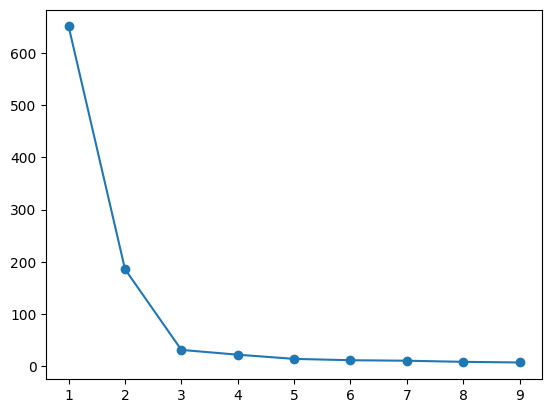

In [13]:
plt.plot(k_rng,sse,marker='o')